# 01 - Baselines on a James et al. clip

Loads one distorted video with its ground truth, computes the temporal mean and median (proposal step 1),
and compares them with metrics. Change `NAME` to try another clip.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from unripple import data
from unripple.baselines import temporal_mean, temporal_median
from unripple.metrics import all_metrics

print(data.james_names())

['BlueTiles', 'BrickWall', 'Bricks', 'Cartoon', 'Checker', 'Dices', 'Elephant', 'Eye', 'HandWritten', 'Math', 'Middle', 'Small', 'Tiny', 'Vision']


In [2]:
NAME = "Checker"
frames, gt = data.load_james(NAME)          # grayscale floats in [0, 1]
print(frames.shape, gt.shape)

(101, 512, 752) (512, 752)


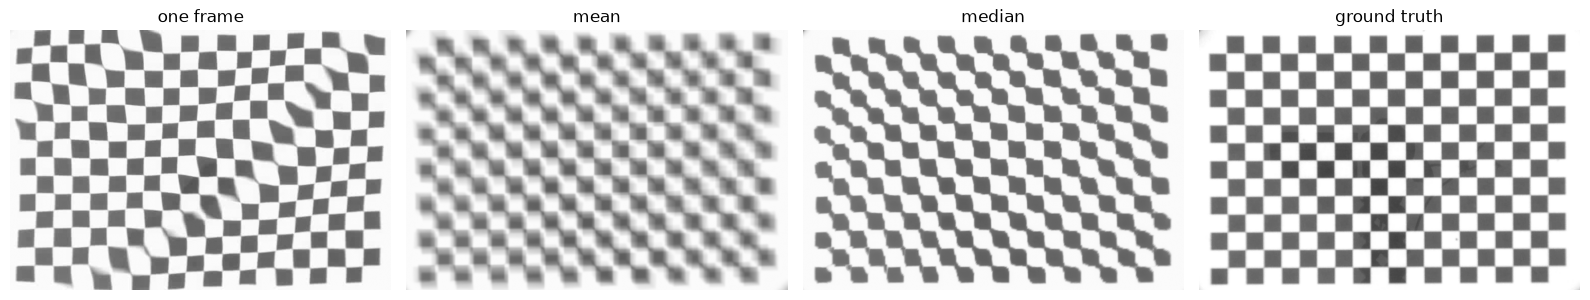

In [3]:
mean, median = temporal_mean(frames), temporal_median(frames)
images = {"one frame": frames[0], "mean": mean, "median": median, "ground truth": gt}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, im) in zip(axes, images.items()):
    ax.imshow(im, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()

In [4]:
import pandas as pd

rows = {k: all_metrics(v, gt) for k, v in images.items() if k != "ground truth"}
pd.DataFrame(rows).T.round(3)

c:\Users\riins\Documents\uni\v\dip\project\un-rippling\.venv\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\riins\Documents\uni\v\dip\project\un-rippling\.venv\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


,psnr,ssim,nmi,rrmse,lpips_vgg
one frame,11.332,0.457,1.038,0.342,0.436
mean,16.840,0.587,1.118,0.181,0.524
median,17.387,0.746,1.154,0.170,0.413


## How much does the water move?

Per-pixel temporal standard deviation of the distorted video. Bright areas are where the water bends the image most.

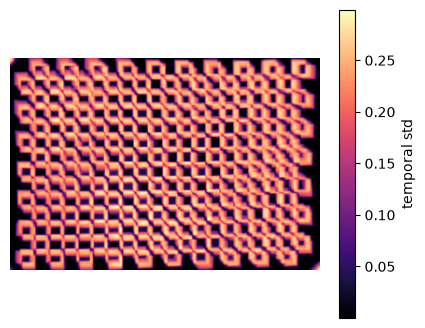

In [5]:
plt.figure(figsize=(5, 4))
plt.imshow(frames.std(axis=0), cmap="magma")
plt.colorbar(label="temporal std")
plt.axis("off");